In [189]:
import pickle
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
import yaml

In [203]:
PATH_OUT = Path.cwd().parents[1] / "results" / "ablation_relative.csv"
DIR_FIGURES = Path.cwd().parents[1] / "results" / "ablation_relative"
PATH_NAME_REPLACEMENTS_CONFIG = Path.cwd().parents[1] / "config" / "renaming.yml"
ESTIMATORS = [
    "bxt_bgso_kronrls",
    "bxt_bgso_logistic",
    "uniform_bxt_bgso",
    "bxt_bgso",
    "nrlmf_bxt_bgso_kronrls",
    "nrlmf_uniform_bxt_bgso",
    "nrlmf_bxt_bgso",
]
MAIN_ESTIMATOR = "bxt_bgso_kronrls"

PATH_LOCAL_RCPARAMS = Path.cwd().parents[1] / "config" / "rc_params.yml"

# \textwidth and \columnwidth in AAAI layout (printed by LaTeX)
TEXT_WIDTH = 7.00137
COLUMN_WIDTH = 3.31314
HALF_COLUMN_WIDTH = COLUMN_WIDTH / 2 - 0.001  # Some small margin
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update(yaml.safe_load(PATH_LOCAL_RCPARAMS.read_text()))

# Specific config
plt.rcParams.update(
    {
        "figure.figsize": (HALF_COLUMN_WIDTH,) * 2,
        "xtick.direction": "out",
        "xtick.major.pad": 1,
        "legend.fontsize": 7,
    }
)

In [191]:
print(plt.rcParams["text.latex.preamble"])

\usepackage{times}
\newcommand{\asterism}{\smash{ \raisebox{-.5ex}{ \setlength{\tabcolsep}{-.5pt} \begin{tabular}{@{}cc@{}} \multicolumn2c*\\[-2ex]*&* \end{tabular}}}}


In [192]:
PATHS_RESULTS = [
    Path.cwd().parents[1] / "results" / "results.csv",
    Path.cwd().parents[1] / "results" / "results_dali.csv",
    Path.cwd().parents[1] / "results" / "results_genoma.csv",
]

In [193]:
renaming = yaml.safe_load(PATH_NAME_REPLACEMENTS_CONFIG.read_text())
renaming["estimator"] = {
    # "nrlmf_bxt_bgso": "Oxytrees[Deep, YR]",
    # "bxt_bgso_logistic": "Oxytrees[Logistic]",
    # "bxt_bgso_kronrls": "Oxytrees",
    # "nrlmf_bxt_bgso_kronrls": "Oxytrees[RLS-Kron, YR]",
    # "dwnn_similarities_bxt_bgso": "Oxytrees[SWN]",
    # "nrlmf_dwnn_similarities_bxt_bgso": "Oxytrees[SWN, YR]",
    # "uniform_bxt_bgso": "Oxytrees[Mean]",
    # "nrlmf_uniform_bxt_bgso": "Oxytrees[Mean, YR]",
    # "nrlmf_bxt_bgso": "Oxytrees[+Deep, +YR]",
    # "bxt_bgso_logistic": "Oxytrees[+Logistic]",
    # "bxt_bgso_kronrls": "Oxytrees",
    # "nrlmf_bxt_bgso_kronrls": "Oxytrees[+YR]",
    # "uniform_bxt_bgso": "Oxytrees[-Leaf model]",
    # "nrlmf_uniform_bxt_bgso": "Oxytrees[-Leaf model, +YR]",
    "bxt_bgso_kronrls": "Oxytrees",
    "nrlmf_bxt_bgso": "[Deep, YR]",
    "bxt_bgso": "[Deep]",
    "bxt_bgso_logistic": "[Logistic]",
    "nrlmf_bxt_bgso_kronrls": "[YR]",
    "uniform_bxt_bgso": "[Mean]",
    "nrlmf_uniform_bxt_bgso": "[Mean, YR]",
}

In [194]:
results_df = pd.concat(
    [pd.read_csv(path) for path in PATHS_RESULTS],
)

In [195]:
results_df = results_df.loc[results_df["estimator"].isin(ESTIMATORS)]
results_df = results_df.set_index(["estimator", "dataset", "fold", "validation_setting"])
results_df = results_df.sort_values(by=["dataset", "fold", "validation_setting", "estimator", "start_time"])
results_df = results_df.loc[~results_df.index.duplicated(keep="last")]
results_df = results_df.drop(columns=["start_time"])
results_df = results_df.rename_axis(columns="metric").stack().rename("value")

In [196]:
display(results_df.loc[results_df.index.duplicated()])
results_df = results_df.loc[~results_df.index.duplicated(keep="last")]

Series([], Name: value, dtype: float64)

In [197]:
df = results_df.reset_index()

# Considering LT and TL together
df["masking_percent"] = df["validation_setting"].str.extract(r"_(\d+)$").astype(float).fillna(0)
df[["validation_setting", "metric"]] = df["metric"].str.rsplit("__", n=1, expand=True)

# The fold name will keep the original setting info
df["fold"] = df["validation_setting"] + "__" + df["fold"].astype(str)
df = df.replace({"validation_setting": {"LT": "LT+TL", "TL": "LT+TL"}})

# Renaming
df = df.replace(
    {
        "estimator": renaming["estimator"],
        "dataset": renaming["dataset"],
        "metric": renaming["metric"],
        "validation_setting": renaming["validation_setting"],
    }
)
df = df.set_index(df.columns.drop("value").tolist())

In [198]:
df = df.dropna()
df

value
estimator  dataset  fold     validation_setting metric masking_percent          
[Deep, YR] Davis    LL__0    Training           AUROC  0.0              0.989278
                                                AUPRC  0.0              0.911792
                    LL_M__0  Transductive       AUROC  0.0              0.952667
                                                AUPRC  0.0              0.318517
[Deep]     Davis    LT__0    Semi-inductive     AUROC  0.0              0.969686
...                                                                          ...
[Mean]     TE-Pirna LL__15   Training           AUPRC  75.0             0.424610
                    TL__15   Semi-inductive     AUROC  75.0             0.518757
                    TT__15   Inductive          AUPRC  75.0             0.049397
                    LL_M__15 Transductive       AUROC  75.0             0.684150
                                                AUPRC  75.0             0.165496

[58008 rows x 1 columns]

In [177]:
df.loc[df.index.duplicated()].sort_index()

value
estimator dataset    fold    validation_setting metric masking_percent          
Oxytrees  DPI-E      LL_M__0 Transductive       AUPRC  25.0             0.612819
                                                       25.0             0.500978
                                                       50.0             0.594467
                                                       50.0             0.454882
                                                       75.0             0.368778
...                                                                          ...
[YR]      miRTarBase TL__3   Semi-inductive     AUPRC  25.0             0.212925
                                                       50.0             0.215136
                                                AUROC  0.0              0.699781
                                                       25.0             0.690897
                                                       50.0             0.687694

[27540 rows x 1 columns]

In [178]:
normalized_df = df.loc[~df.index.duplicated(keep="last")]
normalized_df /= normalized_df.xs(renaming["estimator"][MAIN_ESTIMATOR], level="estimator")
normalized_df = normalized_df.dropna()

In [179]:
def format_p_value(p, alpha=0.05):
    if p > alpha:
        return f"$p \\approx {p:.2g}$"

    n_decimals = int(np.ceil(-np.log10(p)))
    pvalue_noexp = int(np.ceil(p * 10**n_decimals))

    if n_decimals == 1:
        return f"$p < 0.{pvalue_noexp:.0f}$"
    if pvalue_noexp == 10:
        short_pvalue_str = f"10^{{-{n_decimals - 1}}}"
    elif pvalue_noexp == 1:
        short_pvalue_str = f"10^{{-{n_decimals}}}"
    else:
        short_pvalue_str = f"{pvalue_noexp} \\cdot 10^{{-{n_decimals}}}"
    pvalue_eq = f"$p < {short_pvalue_str}$"
    return pvalue_eq

<Figure size 496.671x496.671 with 0 Axes>

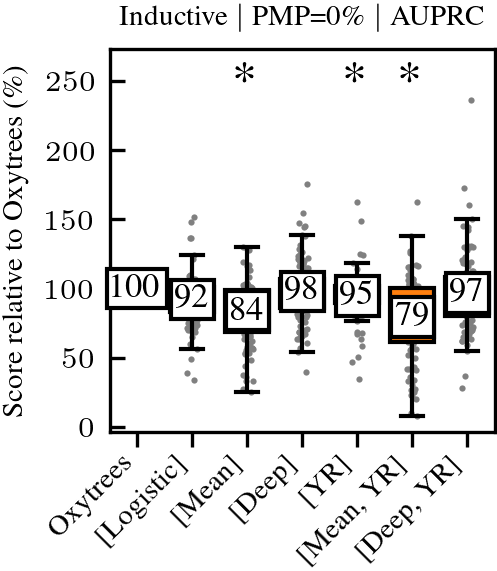

<Figure size 496.671x496.671 with 0 Axes>

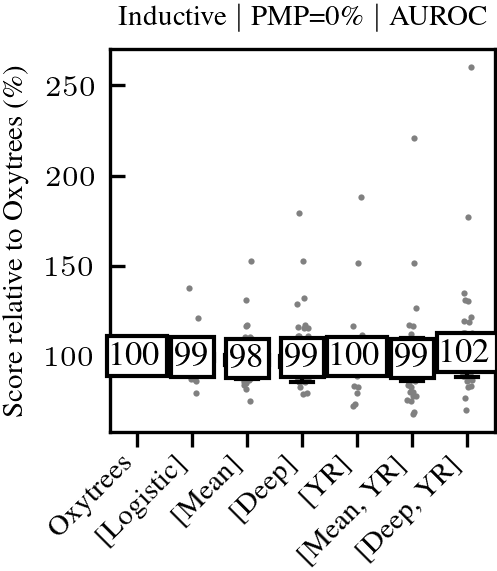

<Figure size 496.671x496.671 with 0 Axes>

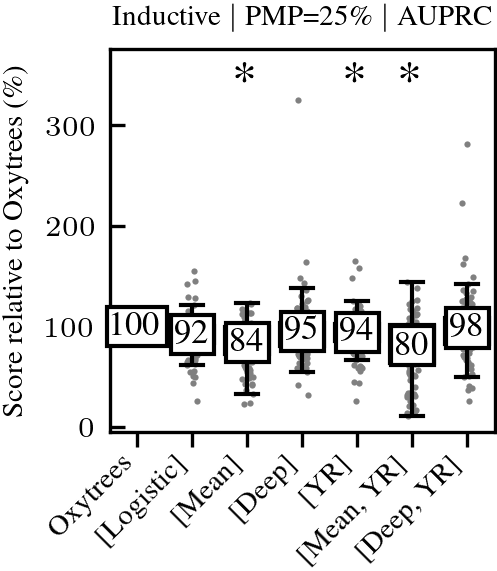

<Figure size 496.671x496.671 with 0 Axes>

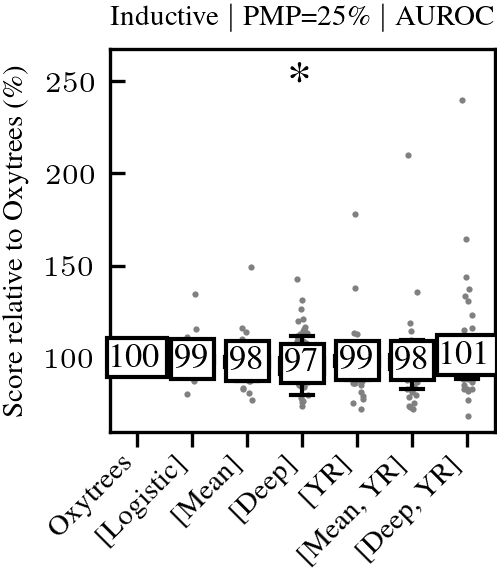

<Figure size 496.671x496.671 with 0 Axes>

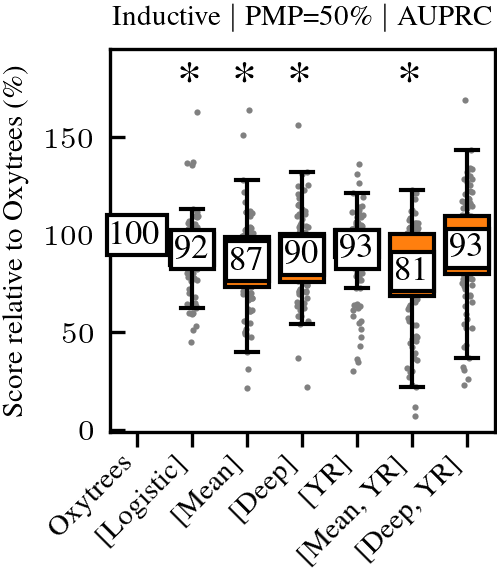

<Figure size 496.671x496.671 with 0 Axes>

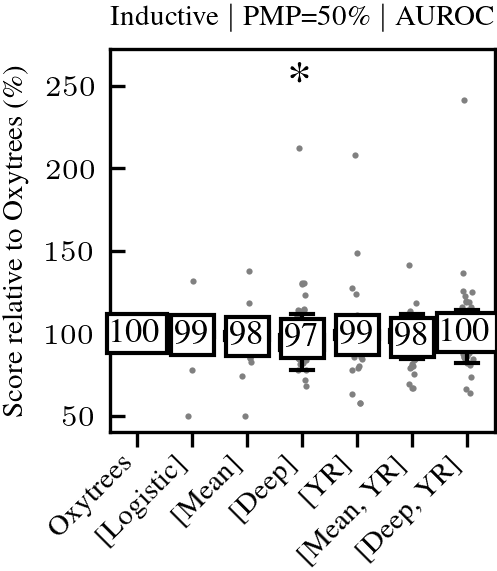

<Figure size 496.671x496.671 with 0 Axes>

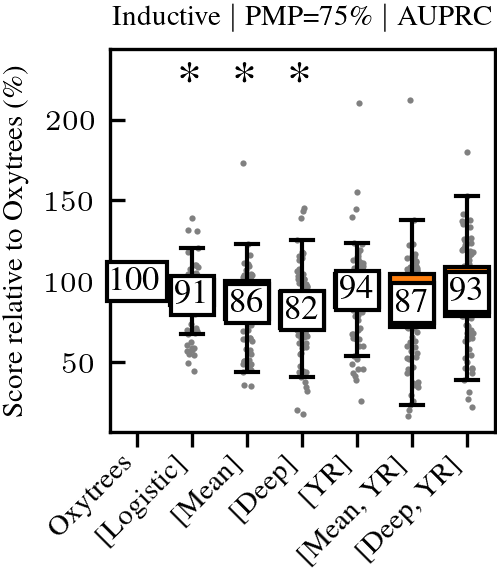

<Figure size 496.671x496.671 with 0 Axes>

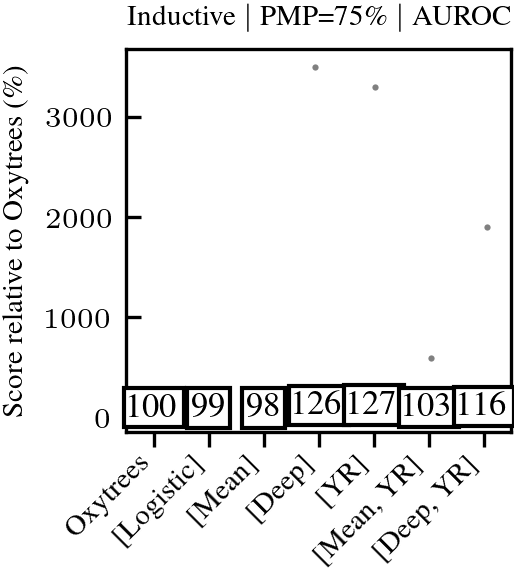

<Figure size 496.671x496.671 with 0 Axes>

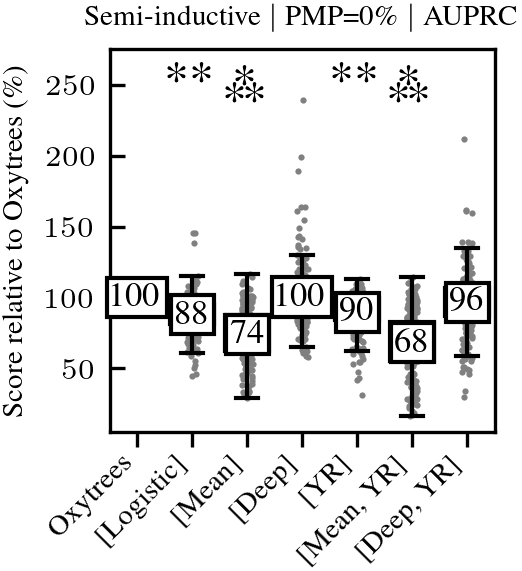

<Figure size 496.671x496.671 with 0 Axes>

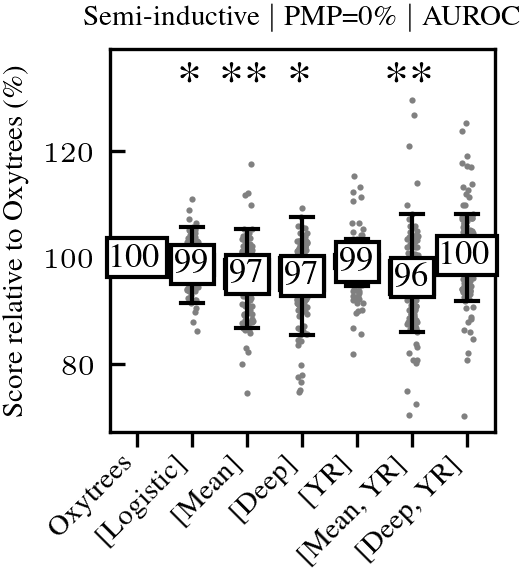

<Figure size 496.671x496.671 with 0 Axes>

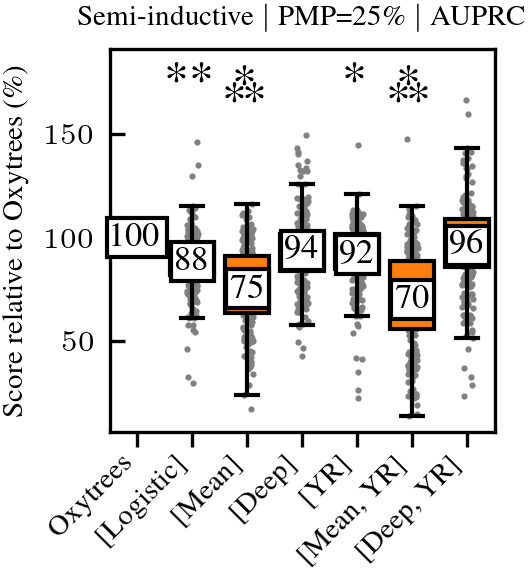

<Figure size 496.671x496.671 with 0 Axes>

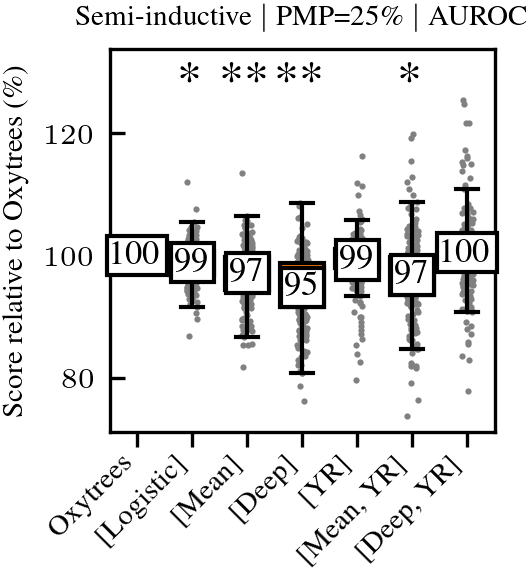

<Figure size 496.671x496.671 with 0 Axes>

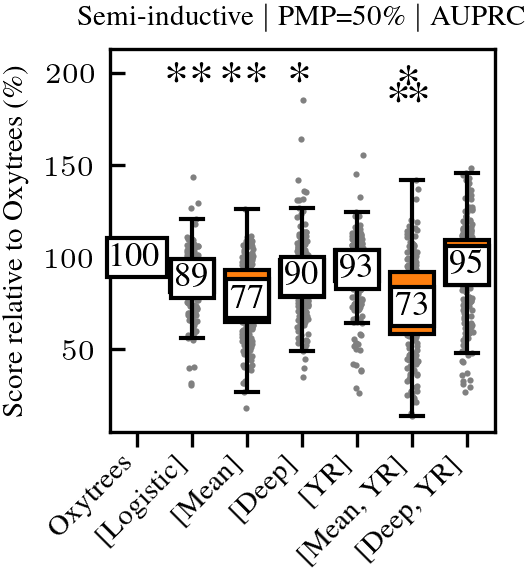

<Figure size 496.671x496.671 with 0 Axes>

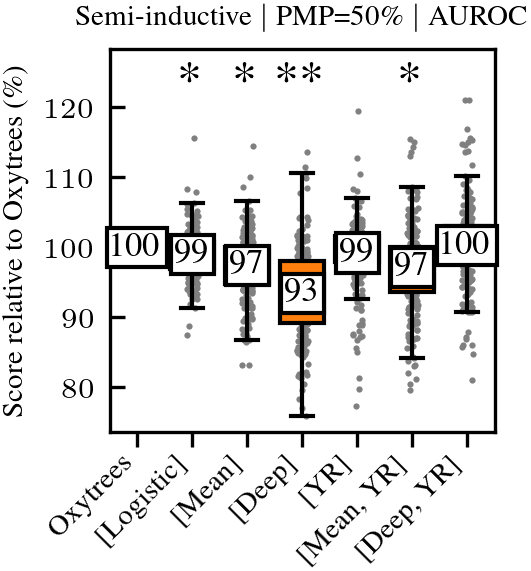

<Figure size 496.671x496.671 with 0 Axes>

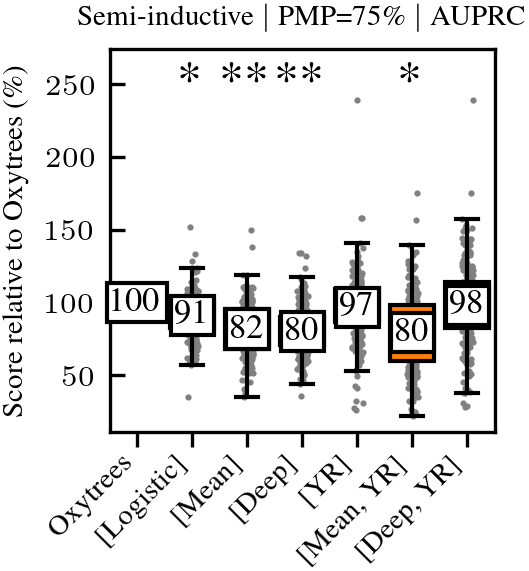

<Figure size 496.671x496.671 with 0 Axes>

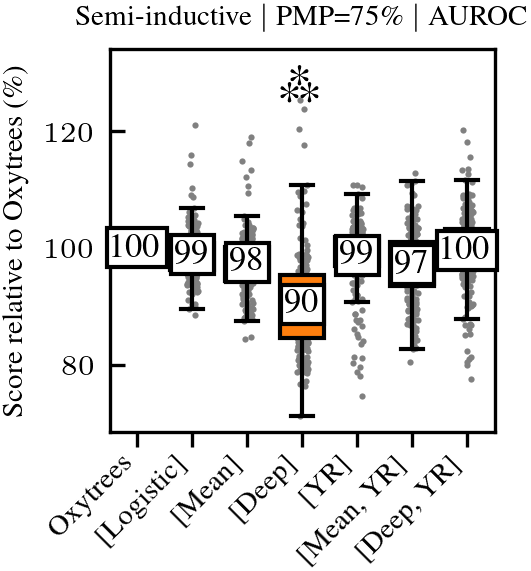

<Figure size 496.671x496.671 with 0 Axes>

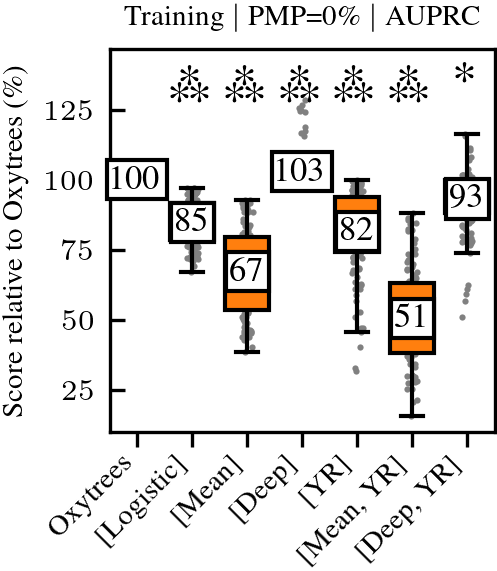

<Figure size 496.671x496.671 with 0 Axes>

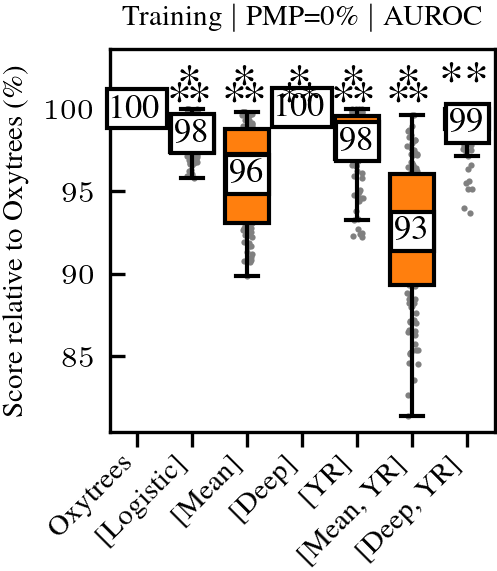

<Figure size 496.671x496.671 with 0 Axes>

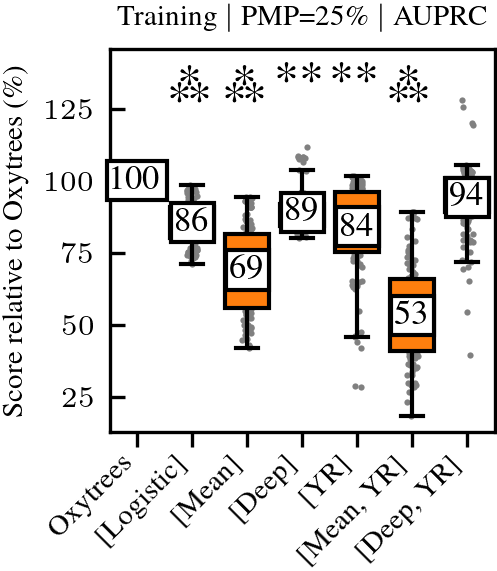

<Figure size 496.671x496.671 with 0 Axes>

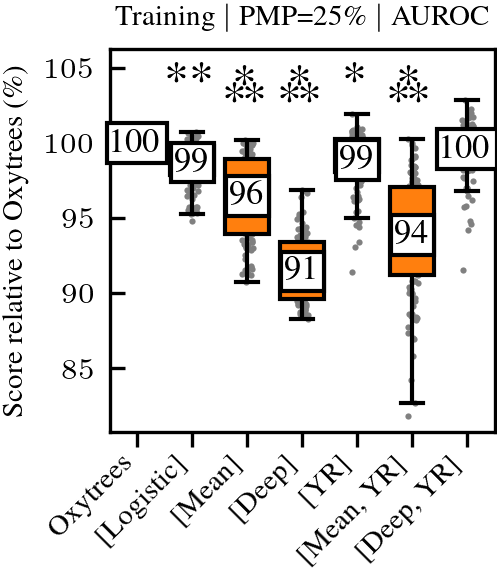

<Figure size 496.671x496.671 with 0 Axes>

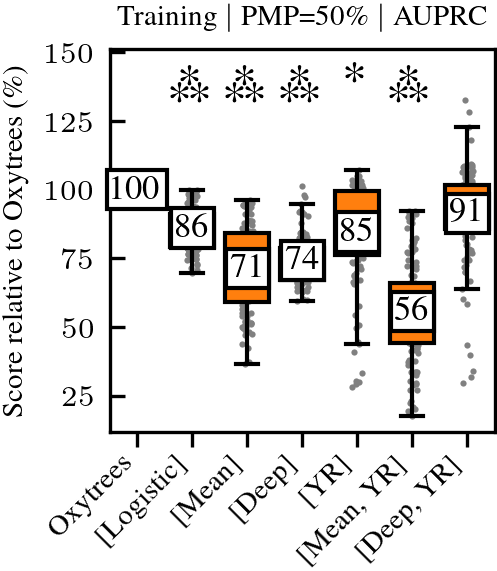

<Figure size 496.671x496.671 with 0 Axes>

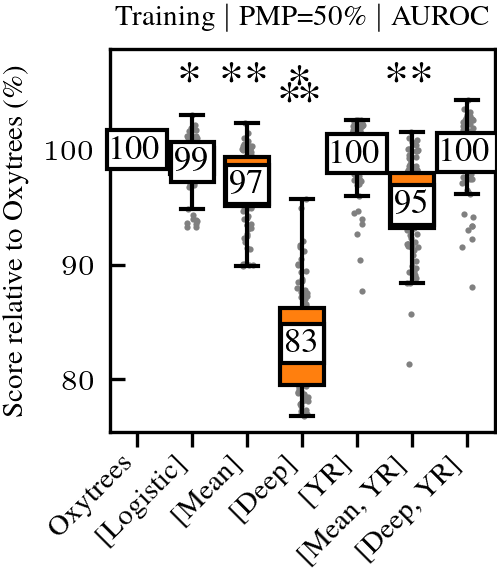

<Figure size 496.671x496.671 with 0 Axes>

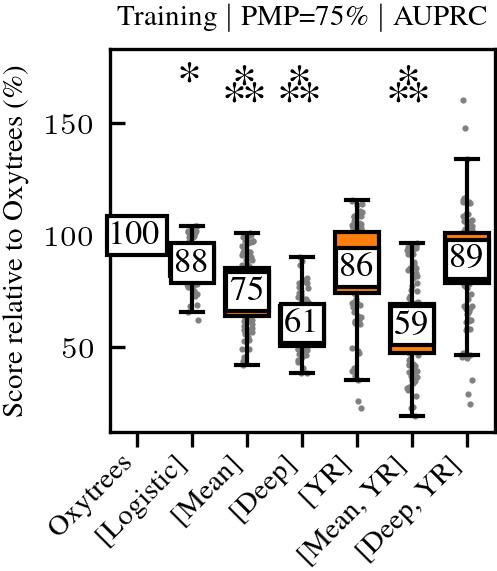

<Figure size 496.671x496.671 with 0 Axes>

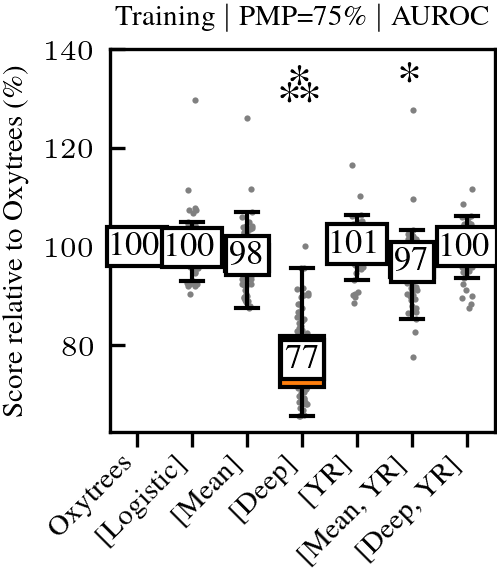

<Figure size 496.671x496.671 with 0 Axes>

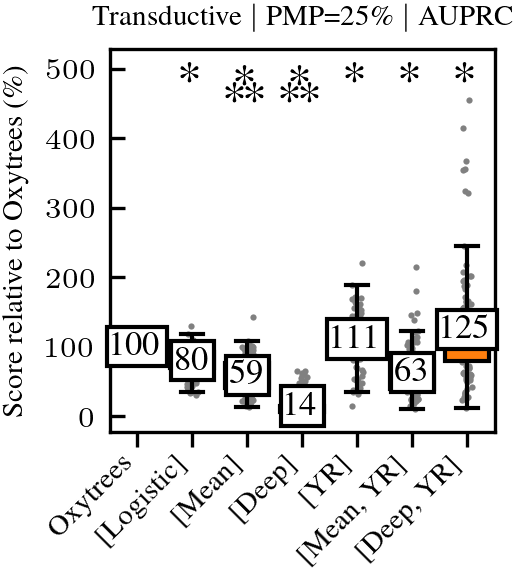

<Figure size 496.671x496.671 with 0 Axes>

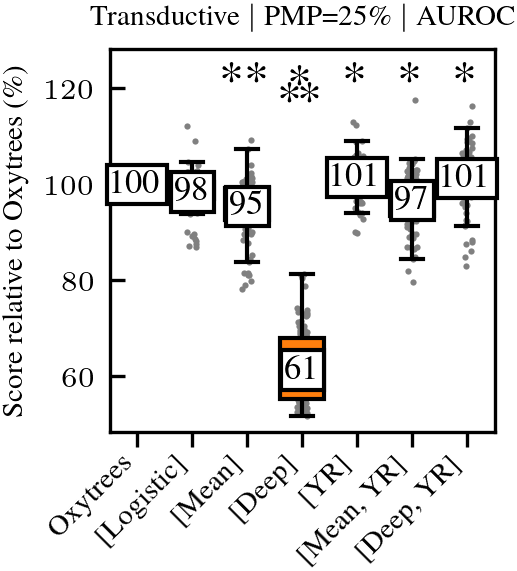

<Figure size 496.671x496.671 with 0 Axes>

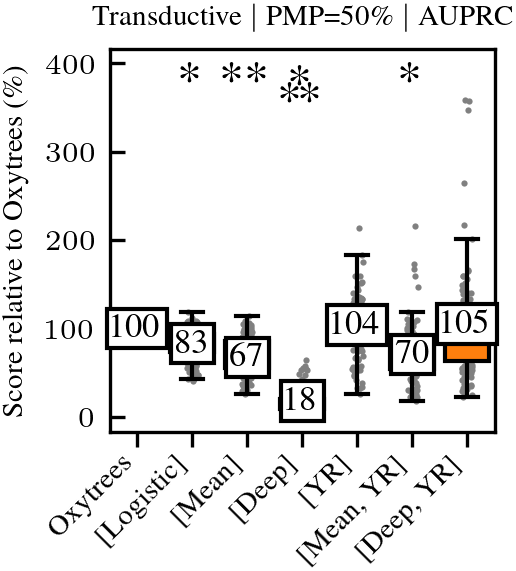

<Figure size 496.671x496.671 with 0 Axes>

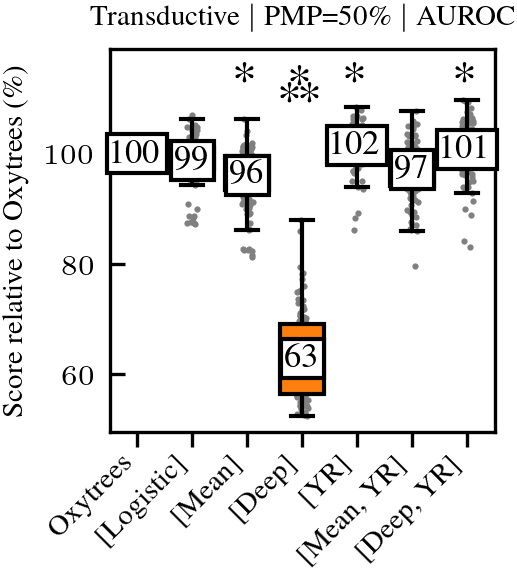

<Figure size 496.671x496.671 with 0 Axes>

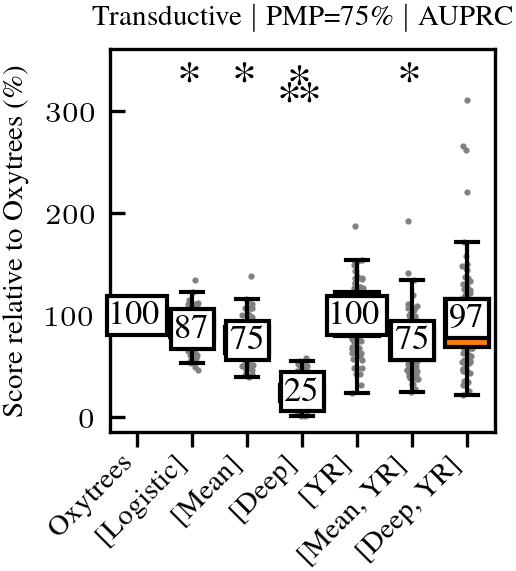

<Figure size 496.671x496.671 with 0 Axes>

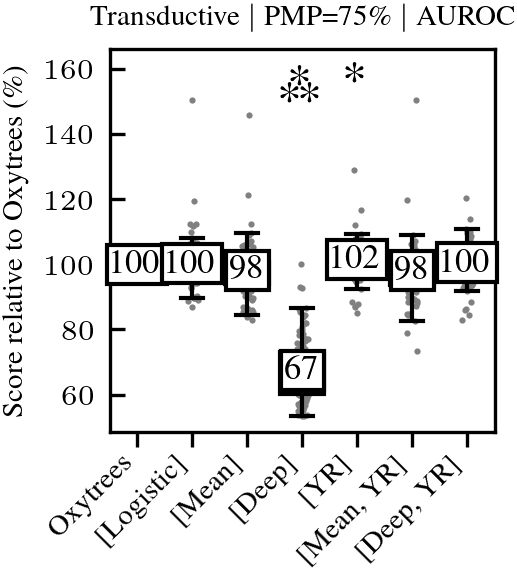

In [204]:
DIR_FIGURES.mkdir(parents=True, exist_ok=True)
TITLE_SEP = " $\\mid$ "
y_label = "Score relative to Oxytrees (\\%)"

alpha = 0.05
assert (
    MAIN_ESTIMATOR == ESTIMATORS[0]
), "The main estimator must be the first in the order list"
order = list(map(renaming["estimator"].get, ESTIMATORS))

for name, group in normalized_df.groupby(
    ["validation_setting", "masking_percent", "metric"]
    # normalized_df.index.droplevel(["estimator", "dataset", "fold"]).names
):
    group = group.copy()
    group["value"] *= 100

    validation_setting, masking_percent, metric = name
    title = TITLE_SEP.join(
        (
            f"{validation_setting}",
            f"PMP={masking_percent:.0f}\\%",
            metric,
        )
    )

    fold_means = group.groupby(["dataset", "estimator"])["value"].mean()
    reference = fold_means.xs(renaming["estimator"][MAIN_ESTIMATOR], level="estimator")
    fold_means = fold_means.drop(
        renaming["estimator"][MAIN_ESTIMATOR], level="estimator"
    )

    significance = fold_means.groupby("estimator").apply(
        lambda x: stats.wilcoxon(x.values, reference.values).pvalue
    )

    group = group.reset_index()

    # display(significance)
    # display(group)

    plt.figure()
    plt.title(title)
    ax = plt.gca()

    sns.stripplot(
        ax=ax,
        data=group,
        x="estimator",
        y="value",
        # hue=hue_col,
        # order=order,
        # palette=["k"] * mean_ranks.index.get_level_values(hue_col).nunique(),
        # color="black",
        jitter=0.1,
        marker=".",
        # color="k",
        color=".5",
        size=3,
        legend=False,
        order=order,
        zorder=-2,
    )

    sns.boxplot(
        ax=ax,
        data=group,
        x="estimator",
        y="value",
        legend=False,
        showmeans=False,
        showfliers=False,
        linecolor="black",
        meanprops={
            "marker": "d",
            "markerfacecolor": "C1",
            "markeredgecolor": "w",
            "zorder": 0,
        },
        boxprops=dict(facecolor="C1"),
        order=order,
    )

    positions = {
        label.get_text(): tick
        for label, tick in zip(ax.get_xticklabels(), ax.get_xticks())
    }

    plt.xticks(rotation=45, ha="right")
    # ax.xaxis.set_tick_params(width=1.5)
    # ax.yaxis.set_tick_params(width=1.5)

    # Add "(mean)" label to each x label
    # x_labels = [
    #     label.get_text() + f" ({means[label.get_text()]:.2g})"
    #     for label in ax.get_xticklabels()
    # ]
    # ax.set_xticklabels(x_labels)

    # plt.ylim(bottom=plt.ylim()[0] - 0.1 * (plt.ylim()[1] - plt.ylim()[0]))
    # for axis in ["top", "bottom", "left", "right"]:
    #     ax.spines[axis].set_linewidth(1.5)

    means = group.groupby("estimator")["value"].mean().reindex(order)

    for xtick in ax.get_xticks():
        plt.annotate(
            # xtick,
            # plt.ylim()[0],
            # means.iloc[xtick],
            f"{means.iloc[xtick]:.0f}",
            # (xtick, plt.ylim()[0]),
            (xtick, means.iloc[xtick]),
            backgroundcolor="white",
            size="small",
            horizontalalignment="center",
            verticalalignment="center",
            bbox=dict(facecolor="white", edgecolor="k", pad=1),
            xycoords="data",
            # xytext=(xtick, plt.ylim()[0]),
            # annotation_clip=False,
        )

    # Annotate p-values at y = 200
    if (significance < alpha).any():
        p_y_pos = ax.get_ylim()[1]
        new_y_top = p_y_pos + 0.1 * np.diff(ax.get_ylim())

        ax.set_ylim(top=new_y_top)

        for xtick, p in zip(ax.get_xticks()[1:], significance[order[1:]]):
            # p_text = format_p_value(p, alpha=alpha)

            if p < 0.0001:
                p_text = "\\asterism"
            elif p < 0.001:
                p_text = "**"
            elif p < alpha:
                p_text = "*"
            else:
                continue

            plt.text(
                s=p_text,
                x=xtick,
                y=p_y_pos,
                # backgroundcolor="white",
                # size="small",
                size="large",
                horizontalalignment="center",
                verticalalignment="center",
                # xycoords="data",
            )

    plt.xticks(rotation=45, ha="right")
    plt.xlabel(None)
    plt.ylabel(y_label)
    out = DIR_FIGURES / f"{validation_setting}_{metric}_{masking_percent:02.0f}.pdf"
    plt.savefig(out)
    with open(out.with_suffix(".pickle"), "wb") as f:
        pickle.dump(plt.gcf(), f)
    plt.show()
    plt.clf()